# X-ray Talbot Wavefront Sensing — a guided tour

This notebook is a **self-contained, standalone** walk-through of the
`escape.wavefront` module: how a single-grating (Talbot) wavefront sensor works,
how to reconstruct the wavefront of an X-ray FEL beam from a detector image, and
how to **back-propagate** the measured beam to its focus.

It only needs `escape`, `numpy` and `matplotlib`. Everything is simulated, so it
runs anywhere with no beamtime required.

**Contents**
1. Geometry and the grating
2. The Talbot self-image (forward simulation)
3. Fourier-fringe demodulation → phase gradients
4. Integrating gradients → the wavefront
5. Finding the focus
6. Recovering aberrations
7. Back-propagation to the focus (with `escape` + dask)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from escape import wavefront as wf
from escape.wavefront import talbot as t

plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['image.cmap'] = 'viridis'

## 1. Geometry and the grating

A grating is placed in the beam; a detector sits a *fractional Talbot distance*
`zT` downstream. The key numbers:

* photon energy → wavelength `λ`
* grating period `dg`
* detector pixel size `dx` (must resolve the fringes: `dx < dg/2`)

The realistic sensor uses a **π-phase checkerboard**; for a clean, didactic
pipeline we use the smooth **mesh** grating whose self-image is a faithful,
magnifying replica.

wavelength   = 1.3051 Angstrom
Talbot dist. = 275.84 mm
Fresnel number over the grating period: 1.0


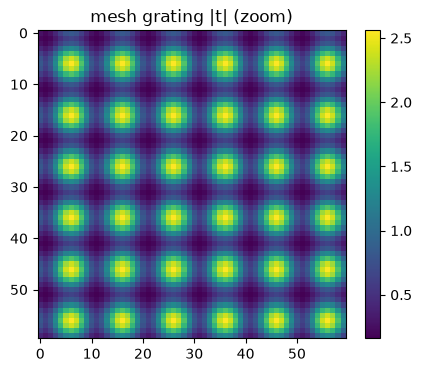

In [2]:
shape  = (512, 512)
dx     = 0.6e-6                                   # detector pixel size (m)
period = 6e-6                                     # grating period (m)
energy = 9500.0                                   # photon energy (eV)
lam    = wf.wavelength_from_energy(energy)        # wavelength (m)
zT     = wf.talbot_distance(period, lam, fraction=0.5)   # half-Talbot plane

print(f'wavelength   = {lam*1e10:.4f} Angstrom')
print(f'Talbot dist. = {zT*1e3:.2f} mm')
print(f'Fresnel number over the grating period: {wf.fresnel_number(period, zT, lam):.1f}')

grating = t.mesh_grating(shape, dx, period)
plt.imshow(np.abs(grating)[:60, :60]); plt.title('mesh grating |t| (zoom)'); plt.colorbar(); plt.show()

## 2. The Talbot self-image (forward simulation)

`simulate_talbot_image` multiplies an incident field by the grating and
Fresnel-propagates it to the detector. With a **flat** incident wavefront we get
our **reference** image; with a curved one we get a **measurement**.

We illuminate with a finite Gaussian beam so the aperture is well defined.

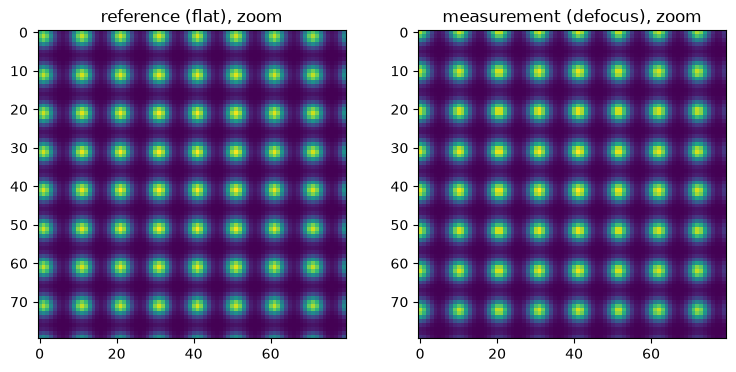

In [3]:
x, y = t._coords(shape, dx)
beam = np.exp(-(x**2 + y**2) / (2 * (80e-6)**2))     # Gaussian illumination

# reference: flat wavefront
reference = wf.simulate_talbot_image(shape, dx, period, lam, zT,
                                     incident_amplitude=beam)

# measurement: beam diverging as from a source 8 m upstream
phi_in = wf.parabolic_phase(shape, dx, radius=8.0, lambda0=lam)
image  = wf.simulate_talbot_image(shape, dx, period, lam, zT,
                                  incident_phase=phi_in,
                                  incident_amplitude=beam)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(reference[220:300, 220:300]); ax[0].set_title('reference (flat), zoom')
ax[1].imshow(image[220:300, 220:300]);     ax[1].set_title('measurement (defocus), zoom')
plt.show()

### What the FFT sees

The self-image is a crossed grid, so its FFT has a bright DC lobe and
**first-order peaks** on the ±x and ±y axes. The reconstruction band-passes one
peak per axis.

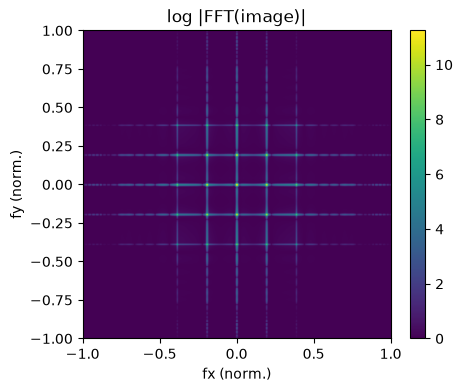

In [4]:
F = np.log1p(np.abs(t._nfft(image)))
plt.imshow(F, extent=[-1,1,-1,1]); plt.title('log |FFT(image)|')
plt.xlabel('fx (norm.)'); plt.ylabel('fy (norm.)'); plt.colorbar(); plt.show()

## 3. Fourier-fringe demodulation → phase gradients

`fourier_fringe_gradients` isolates the +x and +y first orders, forms the
**cross-phase against the reference**, and converts it to the beam's phase
gradients `dφ/dx`, `dφ/dy` (rad/m). The shear relation is

$$\text{res} = f_\text{carrier}\,\lambda\,z_T\;\frac{\partial\phi}{\partial x}.$$

It also returns a **visibility** map that acts as the aperture weight.

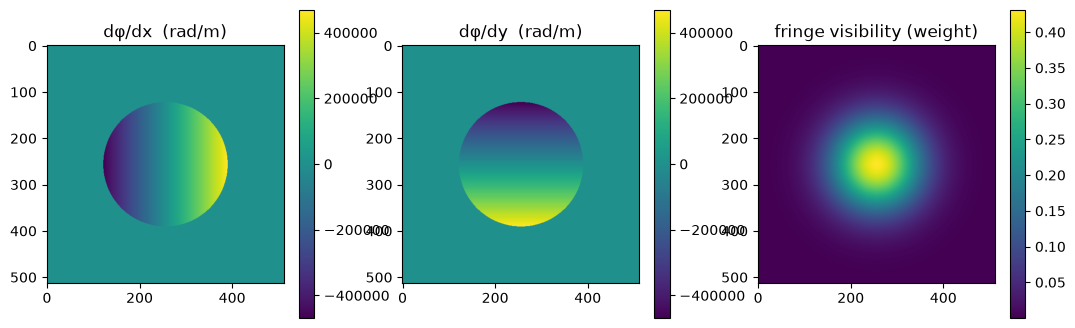

carrier fx, fy (1/m): 166015.625 166015.625


In [5]:
grad_x, grad_y, info = wf.fourier_fringe_gradients(
    image, reference, dx, lam, zT, period=period)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
im0 = ax[0].imshow(grad_x); ax[0].set_title('dφ/dx  (rad/m)'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(grad_y); ax[1].set_title('dφ/dy  (rad/m)'); plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(info['visibility']); ax[2].set_title('fringe visibility (weight)'); plt.colorbar(im2, ax=ax[2])
plt.show()

print('carrier fx, fy (1/m):', info['fx_peak'], info['fy_peak'])

## 4. Integrating gradients → the wavefront

The two gradients are integrated into a single surface with a **weighted
least-squares** solve (the visibility is the weight). Weighting — rather than
hard-masking — is what keeps non-symmetric aberrations honest.

`reconstruct_wavefront` chains steps 3 and 4 and returns a `Wavefront`.

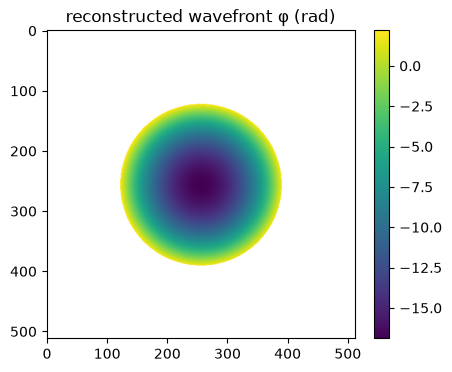

In [6]:
w = wf.reconstruct_wavefront(image, reference, dx=dx,
                             lambda0=lam, zT=zT, period=period)

m = info['mask']
disp = np.where(m, w.phase, np.nan)
plt.imshow(disp); plt.title('reconstructed wavefront φ (rad)'); plt.colorbar(); plt.show()

## 5. Finding the focus

The wavefront curvature gives the radius of curvature `R` (fit directly from the
measured gradients, which is robust). The beam focuses `−R` away from the
detector. Our source was 8 m upstream, so at the detector `R ≈ 8 m + zT`.

In [7]:
print(f'radius of curvature  R = {w.radius_of_curvature():.3f} m   (expected ~{8.0+zT:.3f})')
print(f'distance to focus       = {w.distance_to_focus():.3f} m')
print(f'residual aberration rms = {w.rms(remove_sphere=True)*1e3:.2f} mrad')

radius of curvature  R = 8.265 m   (expected ~8.276)
distance to focus       = -8.265 m
residual aberration rms = 75.87 mrad


## 6. Recovering aberrations

Add a known aberration (here astigmatism) on top and check that the shape comes
back. The sensor is differential, so smooth aberrations are recovered with high
fidelity.

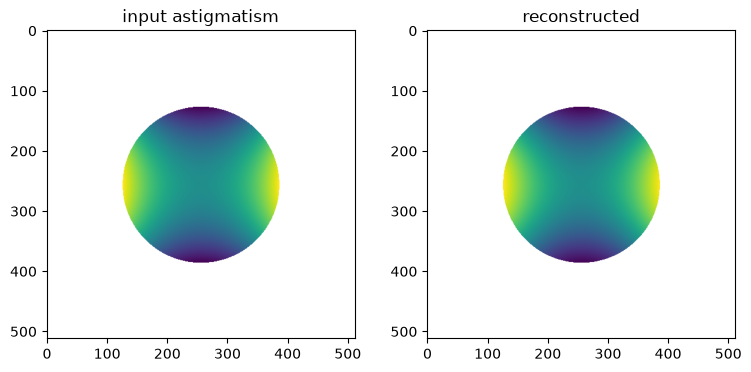

shape correlation = 0.9997


In [8]:
Zx, Zy = x / (2*80e-6), y / (2*80e-6)
astig = 5.0 * (Zx**2 - Zy**2)                    # radians
img_a = wf.simulate_talbot_image(shape, dx, period, lam, zT,
                                 incident_phase=astig, incident_amplitude=beam)
wa = wf.reconstruct_wavefront(img_a, reference, dx=dx, lambda0=lam, zT=zT, period=period)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(np.where(wa.info['mask'], astig, np.nan)); ax[0].set_title('input astigmatism')
ax[1].imshow(np.where(wa.info['mask'], wa.phase - wa.phase[wa.info['mask']].mean(), np.nan)); ax[1].set_title('reconstructed')
plt.show()

cm = (x**2 + y**2) < (0.6*80e-6)**2
corr = np.corrcoef((astig-astig[cm].mean())[cm], (wa.phase-wa.phase[cm].mean())[cm])[0,1]
print(f'shape correlation = {corr:.4f}')

## 7. Back-propagation to the focus (with `escape` + dask)

The reconstructed **complex field** `amplitude · exp(iφ)` can be propagated to
any plane by the angular-spectrum method — *negative* distance walks it
**upstream toward the focus**.

For a real run you have one field per FEL pulse. `propagate_array` propagates a
whole **lazy `escape.Array`** of fields blockwise over dask, with no per-event
Python loop. Here we mock a stack of pulses with a strongly converging beam.

reconstructed focus distance = 3.722 m
escape Array: (8, 512, 512) complex64 — lazy: True


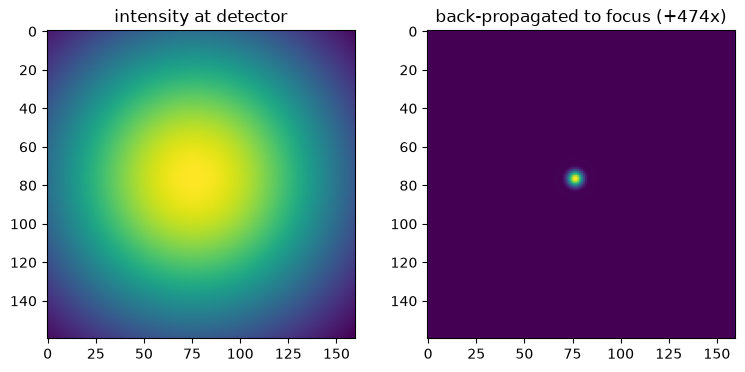

In [9]:
import escape
import dask.array as da

# a strongly converging beam: focus a few metres downstream of the detector
phi_conv = wf.parabolic_phase(shape, dx, radius=-4.0, lambda0=lam)
img_c = wf.simulate_talbot_image(shape, dx, period, lam, zT,
                                 incident_phase=phi_conv, incident_amplitude=beam)
wc = wf.reconstruct_wavefront(img_c, reference, dx=dx, lambda0=lam, zT=zT, period=period)
zf = wc.distance_to_focus()
print(f'reconstructed focus distance = {zf:.3f} m')

# build a lazy escape.Array: 8 pulses (here identical) of the reconstructed field
field = wc.field.astype(np.complex64)
stack = da.stack([da.from_array(field)] * 8).rechunk((2, *shape))
fields = escape.Array(data=stack, index=np.arange(8))
print('escape Array:', fields.data.shape, fields.data.dtype, '— lazy:', fields.is_dask_array())

# propagate every pulse to the focus (lazy), then intensity
focus = wf.propagate_array(fields, dx=dx, z=zf, lambda0=lam)
intensity = focus.map_index_blocks(lambda b: np.abs(b)**2, dtype='f4')
I_focus = intensity[0].data.compute().squeeze()
I_det   = np.abs(field)**2

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(I_det[180:340, 180:340]);   ax[0].set_title('intensity at detector')
ax[1].imshow(I_focus[180:340, 180:340]); ax[1].set_title(f'back-propagated to focus (+{I_focus.max()/I_det.max():.0f}x)')
plt.show()

### Recap

* A **reference** image fixes the fringe carrier; the measurement's cross-phase
  against it is the sheared wavefront — defocus and all.
* Gradients → wavefront by **weighted least-squares** integration.
* Curvature → **focus distance**; the complex field → **back-propagation** to any
  plane, lazily across a run with `escape` + dask.

The propagation is pure NumPy/dask FFTs on purpose — fast and memory-clean.
See the module docs for how to fold a `numba` kernel into `map_index_blocks`
without the thread-pool / reference leaks that bite `jungfrau_utils`-style
corrections.

## References

**Method** — Liu, Seaberg *et al.*:

1. Y. Liu, M. Seaberg, Y. Feng, K. Li, Y. Ding, G. Marcus, D. Fritz, X. Shi, W. Grizolli, L. Assoufid, P. Walter & A. Sakdinawat, "X-ray free-electron laser wavefront sensing using the fractional Talbot effect", *J. Synchrotron Rad.* **27**(2), 254–261 (2020). doi:[10.1107/S1600577519017107](https://doi.org/10.1107/S1600577519017107)
2. Y. Liu, M. Seaberg, D. Zhu *et al.*, "High-accuracy wavefront sensing for x-ray free electron lasers", *Optica* **5**(8), 967–975 (2018). doi:[10.1364/OPTICA.5.000967](https://doi.org/10.1364/OPTICA.5.000967)

**Reference software** (M. Seaberg, SLAC): [`lcls_beamline_toolbox`](https://github.com/mseaberg/lcls_beamline_toolbox), [`wfs_interface`](https://github.com/mseaberg/wfs_interface).

**Algorithms**: Takeda, Ina & Kobayashi, *JOSA* **72**, 156 (1982) — Fourier-fringe demodulation; Frankot & Chellappa, *IEEE PAMI* **10**, 439 (1988) — gradient integration; Herráez *et al.*, *Appl. Opt.* **41**, 7437 (2002) — 2-D phase unwrap; J. W. Goodman, *Introduction to Fourier Optics* (2005) — angular-spectrum propagation.
